# 🧠 Mental Health Intelligence Platform

## Phase 7 — Machine Learning

### Overview

This notebook develops predictive machine learning models to identify whether an employee is likely to seek professional mental health treatment.

Unlike previous notebooks that focused on understanding the data, this phase focuses on prediction.

---

### Objectives

- Build multiple classification models
- Compare model performance
- Select the best model
- Interpret important features
- Save the trained model for deployment

## Imports

In [48]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [49]:
df = pd.read_csv("../data/processed/ml_ready_dataset.csv")

print(df.shape)

df.head()

(3082, 62)


,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,...,age,gender,country_live,state_live,race,country_work,state_work,age_group,workplace_support_score,sought_treatment
0,2014,NaN,6-25,Yes,NaN,Yes,Don't Know,No,Yes,Yes,...,NaN,Male,NaN,New York,Other,South Africa,NaN,NaN,3,Yes
1,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,...,NaN,Other,NaN,Massachusetts,More than one of the above,Indonesia,NaN,NaN,0,No
2,2014,NaN,6-25,Yes,NaN,No,No,No,No,Don't Know,...,NaN,Other,NaN,Texas,More than one of the above,Germany,NaN,NaN,0,No
3,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,...,NaN,Other,NaN,Other,I prefer not to answer,Canada,NaN,NaN,0,Yes
4,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,...,NaN,Male,NaN,Ohio,White,Ethiopia,NaN,NaN,1,No


## Remove Features with Extremely High Missing Values

Several survey questions were introduced only in specific survey years, resulting in more than 90% missing values.

These features provide very limited information for predictive modelling and are removed.

In [50]:
# Calculate missing percentage for every column
missing_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Column": missing_percent.index,
    "Missing (%)": missing_percent.values
})

missing_df.head(20)

,Column,Missing (%)
0,productivity_percent_affected,93.705386
1,identified_affected_career,92.796885
2,reveal_to_clients,91.596366
3,coverage_mental_health,91.596366
4,reveal_to_coworkers,91.596366
5,know_resources,91.596366
6,team_reaction_if_knew,86.469825
7,willing_to_interview,86.469825
8,state_work,73.491239
9,observed_unsupportive_response,62.005191


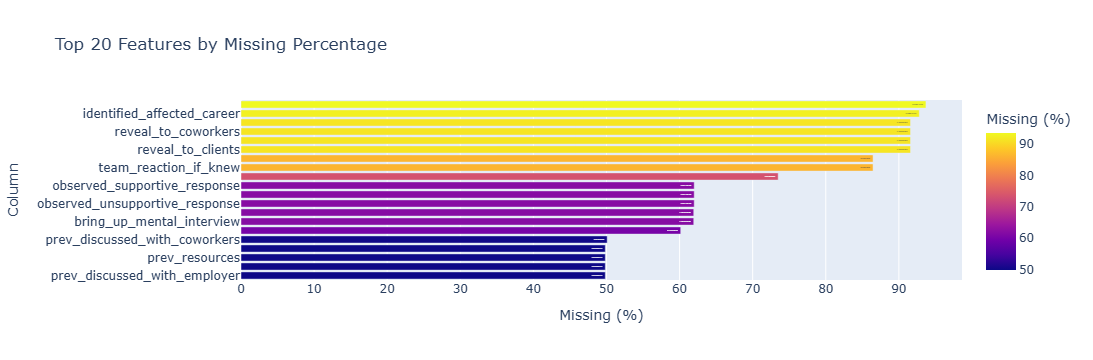

In [51]:
import plotly.express as px

fig = px.bar(
    missing_df.head(20),
    x="Missing (%)",
    y="Column",
    orientation="h",
    title="Top 20 Features by Missing Percentage",
    color="Missing (%)",
    text="Missing (%)"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [52]:
# Define threshold
MISSING_THRESHOLD = 80

# Identify columns exceeding threshold
high_missing_cols = missing_percent[
    missing_percent > MISSING_THRESHOLD
].index.tolist()

print(f"Columns to remove ({len(high_missing_cols)}):")
print(high_missing_cols)

Columns to remove (8):
['productivity_percent_affected', 'identified_affected_career', 'reveal_to_clients', 'coverage_mental_health', 'reveal_to_coworkers', 'know_resources', 'team_reaction_if_knew', 'willing_to_interview']


In [53]:
df = df.drop(columns=high_missing_cols)

print(f"New Shape: {df.shape}")

New Shape: (3082, 54)


In [54]:
remaining_missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

remaining_missing.head(15)

state_work                           73.491239
observed_supportive_response         62.005191
country_live                         62.005191
observed_unsupportive_response       62.005191
have_prev_employers                  61.940299
bring_up_mental_interview            61.940299
self_employed                        60.155743
prev_discussed_with_coworkers        50.097339
prev_resources                       49.837768
prev_comfort_supervisor              49.837768
prev_know_options                    49.837768
prev_employer_importance_physical    49.837768
prev_comfort_coworkers               49.837768
prev_discussed_with_employer         49.837768
prev_benefits                        49.837768
dtype: float64

## Separate Features and Target

In [55]:
TARGET = "sought_treatment"

X = df.drop(columns=TARGET)

y = df[TARGET]

## Train-Test Split

The dataset is divided into training and testing subsets.

Stratified sampling is used to preserve the distribution of the target variable.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

## Build Preprocessing Pipeline

In [57]:
numeric_features = X_train.select_dtypes(

    include=["int64","float64"]

).columns.tolist()

In [58]:
categorical_features = X_train.select_dtypes(

    include=["object","category","string"]

).columns.tolist()

In [59]:
numeric_pipeline = Pipeline([

    ("imputer",SimpleImputer(strategy="median")),

    ("scaler",StandardScaler())

])

categorical_pipeline = Pipeline([

    ("imputer",SimpleImputer(strategy="constant",fill_value="Not Asked")),

    ("encoder",OneHotEncoder(handle_unknown="ignore"))

])

In [60]:
preprocessor = ColumnTransformer(

    [

        ("num",numeric_pipeline,numeric_features),

        ("cat",categorical_pipeline,categorical_features)

    ]

)

# Logistic Regression

In [61]:
logistic_model = Pipeline([

    ("preprocessor",preprocessor),

    ("classifier",LogisticRegression(max_iter=1000))

])

logistic_model.fit(

    X_train,

    y_train

)

logistic_pred = logistic_model.predict(X_test)

In [62]:
print(classification_report(

    y_test,

    logistic_pred

))

              precision    recall  f1-score   support

          No       0.77      0.78      0.77       274
         Yes       0.82      0.82      0.82       343

    accuracy                           0.80       617
   macro avg       0.80      0.80      0.80       617
weighted avg       0.80      0.80      0.80       617



# Decision Tree

In [63]:
tree_model = Pipeline([

    ("preprocessor",preprocessor),

    ("classifier",DecisionTreeClassifier(random_state=42))

])

tree_model.fit(

    X_train,

    y_train

)

tree_pred = tree_model.predict(X_test)

In [64]:
print(classification_report(

    y_test,

    tree_pred

))

              precision    recall  f1-score   support

          No       0.69      0.69      0.69       274
         Yes       0.75      0.76      0.75       343

    accuracy                           0.73       617
   macro avg       0.72      0.72      0.72       617
weighted avg       0.73      0.73      0.73       617



# Random Forest

In [65]:
forest_model = Pipeline([

    ("preprocessor",preprocessor),

    ("classifier",RandomForestClassifier(

        random_state=42,

        n_estimators=300

    ))

])

forest_model.fit(

    X_train,

    y_train

)

forest_pred = forest_model.predict(X_test)

In [66]:
print(classification_report(

    y_test,

    forest_pred

))

              precision    recall  f1-score   support

          No       0.79      0.76      0.78       274
         Yes       0.82      0.84      0.83       343

    accuracy                           0.80       617
   macro avg       0.80      0.80      0.80       617
weighted avg       0.80      0.80      0.80       617



## Model Comparison

In [67]:
models = {

    "Logistic Regression": logistic_model,

    "Decision Tree": tree_model,

    "Random Forest": forest_model

}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test,pred),

        "Precision": precision_score(y_test,pred,pos_label="Yes"),

        "Recall": recall_score(y_test,pred,pos_label="Yes"),

        "F1 Score": f1_score(y_test,pred,pos_label="Yes")

    })

results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.799028,0.821114,0.816327,0.818713
1,Decision Tree,0.726094,0.751445,0.758017,0.754717
2,Random Forest,0.803890,0.815341,0.836735,0.825899


## Hyperparameter Tuning

The baseline Random Forest classifier produced the best overall performance among the evaluated models.

To further improve predictive performance, hyperparameter tuning is performed using Grid Search with cross-validation.

Grid Search systematically evaluates multiple parameter combinations and selects the configuration that maximizes model performance.

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
param_grid = {

    "classifier__n_estimators": [100, 200, 300],

    "classifier__max_depth": [None, 10, 20, 30],

    "classifier__min_samples_split": [2, 5, 10],

    "classifier__min_samples_leaf": [1, 2, 4],

    "classifier__max_features": ["sqrt", "log2"]

}

In [70]:
grid_search = GridSearchCV(

    estimator=forest_model,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    verbose=2

)

In [71]:
grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more a

In [72]:
print("Best Parameters:\n")

print(grid_search.best_params_)

Best Parameters:

{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [73]:
print(

    f"Best CV F1 Score: {grid_search.best_score_:.4f}"

)

Best CV F1 Score: nan


In [74]:
best_model = grid_search.best_estimator_

pred = best_model.predict(X_test)

In [75]:
print(

    classification_report(

        y_test,

        pred

    )

)

              precision    recall  f1-score   support

          No       0.77      0.75      0.76       274
         Yes       0.81      0.83      0.82       343

    accuracy                           0.79       617
   macro avg       0.79      0.79      0.79       617
weighted avg       0.79      0.79      0.79       617



In [76]:
print(f"Accuracy : {accuracy_score(y_test,pred):.4f}")

print(f"Precision: {precision_score(y_test,pred,pos_label='Yes'):.4f}")

print(f"Recall   : {recall_score(y_test,pred,pos_label='Yes'):.4f}")

print(f"F1 Score : {f1_score(y_test,pred,pos_label='Yes'):.4f}")

Accuracy : 0.7925
Precision: 0.8063
Recall   : 0.8251
F1 Score : 0.8156


In [77]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline Random Forest",

        "Tuned Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test,forest_pred),

        accuracy_score(y_test,pred)

    ],

    "Precision":[

        precision_score(y_test,forest_pred,pos_label="Yes"),

        precision_score(y_test,pred,pos_label="Yes")

    ],

    "Recall":[

        recall_score(y_test,forest_pred,pos_label="Yes"),

        recall_score(y_test,pred,pos_label="Yes")

    ],

    "F1 Score":[

        f1_score(y_test,forest_pred,pos_label="Yes"),

        f1_score(y_test,pred,pos_label="Yes")

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.803890,0.815341,0.836735,0.825899
1,Tuned Random Forest,0.792545,0.806268,0.825073,0.815562


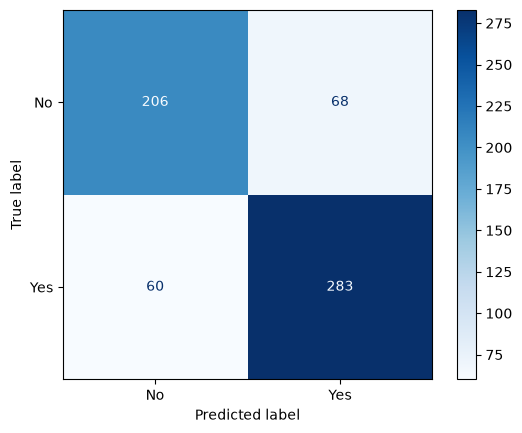

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,

    y_test,

    cmap="Blues"

)

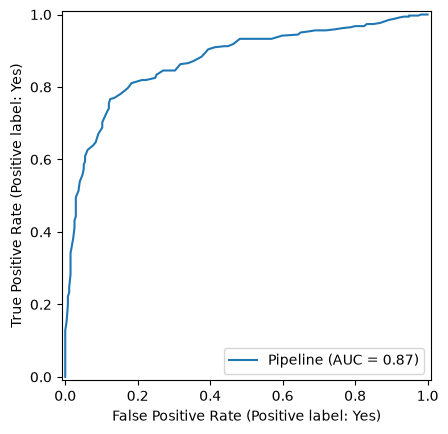

In [79]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(

    best_model,

    X_test,

    y_test,

    pos_label="Yes"

)

In [80]:
import json

metadata = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, pos_label="Yes"),
    "recall": recall_score(y_test, pred, pos_label="Yes"),
    "f1_score": f1_score(y_test, pred, pos_label="Yes"),
    "best_parameters": grid_search.best_params_
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [81]:
joblib.dump(

    best_model,

    "../models/best_model.pkl"

)

joblib.dump(

    preprocessor,

    "../models/preprocessor.pkl"

)

print("Model saved successfully.")

Model saved successfully.
